# 04 - CODE-15% exploratory data analysis

CODE-15% is a 15% sample of the Brazilian CODE telehealth dataset: 345,779 exams at 400 Hz, with
six automatic diagnosis flags. The project downloaded it but has **not used it for any model**,
because two properties were unresolved: the amplitude unit and the true recording duration. This
notebook resolves both from the data, using **all 18 waveform parts**.

We reuse the references from the earlier notebooks: PTB-XL and the Challenge sources for amplitude
in mV, and the validated heart-rate estimator.

In [1]:
import sys
from pathlib import Path

ROOT = next(path for path in [Path.cwd(), *Path.cwd().parents] if (path / "pyproject.toml").exists())
sys.path.insert(0, str(ROOT))

In [2]:
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from eda.code15 import (
    EXPORT_ARCHIVE,
    LABELS,
    PREPARED_DIR,
    RAW_DIR,
    code15_summary,
    lead_features,
    load_exams,
    padding_table,
    read_native_tracing,
)
from eda.cross import combined_summary
from eda.ptbxl import load_metadata
from eda.ptbxl_signals import FEATURE_CACHE as PTBXL_FEATURES
from eda.signals import LEADS, plot_ecg, problem_counts

pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 30)
pd.set_option("display.precision", 3)
plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3})

exams = load_exams()

## 1. Where the waveforms are

The download receipt (`data/acquisition/code_15pct.json`) lists 18 verified ZIP archives, but
`data/raw/code-15pct/` only holds `exams.csv`. The waveforms were moved: `outputs/data_export/`
contains a single `tar.xz` transfer bundle with all 18 parts as HDF5 files. Its marker files record
that the contents were verified byte for byte before the ZIPs were deleted.

In [3]:
export_dir = EXPORT_ARCHIVE.parent
receipt = json.loads((ROOT / "data/acquisition/code_15pct.json").read_text())
display(pd.Series({
    "acquisition receipt state": receipt["state"],
    "files now in data/raw/code-15pct": ", ".join(sorted(path.name for path in RAW_DIR.iterdir())),
    "export archive": EXPORT_ARCHIVE.name,
    "export archive size (GB)": round(EXPORT_ARCHIVE.stat().st_size / 1e9, 1),
    "content check": (export_dir / "CODE_CONTENT_VERIFIED").read_text().strip(),
    "ZIP removal": (export_dir / "CODE_SOURCE_ZIPS_REMOVED").read_text().strip(),
}).to_frame("value"))

,value
acquisition receipt state,complete
files now in data/raw/code-15pct,exams.csv
export archive,code_15pct_waveforms_2026-09-25.tar.xz
export archive size (GB),38.9
content check,All 19 archive members match their original fi...
ZIP removal,Verified and removed the 18 source ZIPs at 202...


**Finding: the data is complete, but the documentation is out of date.** Nothing is lost. The
archive's SHA-256 matches `CODE_SHA256SUMS` (checked with `sha256sum -c` for this analysis), and the
project verified every HDF5 inside against the original ZIP contents before removing the ZIPs. The
problem is findability: the acquisition receipt still says the ZIPs are in `data/raw`, and neither
`docs/data-sources.md` nor the data-versioning guide mentions the move. Also, the original ZIPs, and
with them Zenodo's MD5 checksums, can no longer be checked directly; integrity now rests on the
project's own verification step.

Fully extracted, the archive needs 68 GB, more than the free disk space. So `eda.code15` streams it
and extracts one part at a time (about 3 minutes per part, 50 minutes in total), caches its
statistics and deletes it. Everything below covers all 345,797 stored tracings.

## 2. Metadata, missing values and labels

In [4]:
display(exams.isna().mean()[lambda values: values > 0].round(3).to_frame("missing fraction"))
per_patient = exams.groupby("patient_id").size()
display(pd.Series({
    "exams": len(exams),
    "patients": exams["patient_id"].nunique(),
    "patients with more than one exam": int((per_patient > 1).sum()),
    "most exams for one patient": int(per_patient.max()),
    "male share": exams["is_male"].mean(),
    "median age": exams["age"].median(),
}).to_frame("value").round(3))

,missing fraction
death,0.324
timey,0.324


,value
exams,345779.000
patients,233770.000
patients with more than one exam,66929.000
most exams for one patient,38.000
male share,0.403
median age,54.000


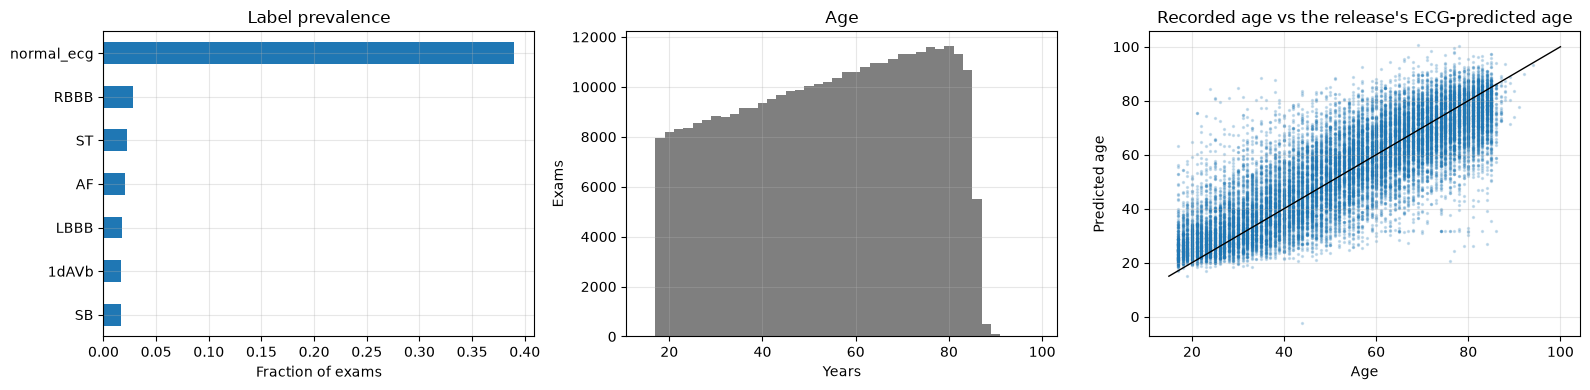

any of the six flags,False,True,All
normal_ecg,,,
False,173347,37775,211122
True,134657,0,134657
All,308004,37775,345779


In [5]:
exams["any_flag"] = exams[LABELS].any(axis=1)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
exams[[*LABELS, "normal_ecg"]].mean().sort_values().plot.barh(ax=axes[0], color="tab:blue")
axes[0].set(title="Label prevalence", xlabel="Fraction of exams")
axes[1].hist(exams["age"], bins=np.arange(15, 101, 2), color="tab:gray")
axes[1].set(title="Age", xlabel="Years", ylabel="Exams")
sample = exams.sample(20000, random_state=0)
axes[2].scatter(sample["age"], sample["nn_predicted_age"], s=2, alpha=0.2)
axes[2].plot([15, 100], [15, 100], color="black", linewidth=1)
axes[2].set(title="Recorded age vs the release's ECG-predicted age", xlabel="Age", ylabel="Predicted age")
plt.tight_layout()
plt.show()
display(pd.crosstab(exams["normal_ecg"], exams["any_flag"], margins=True).rename_axis(
    index="normal_ecg", columns="any of the six flags"))

**Finding: a younger outpatient population with sparse labels.**

- Only `death` and `timey` (follow-up) are missing, for 32% of exams. They are survival outcomes,
  not needed here.
- 233,770 patients, 29% of them with repeat exams (up to 38). Any split has to be by patient, as in
  the project's manifest.
- The population is younger (median age 54) and mostly female (60%), unlike every other source.
- The six diagnosis flags are rare (1.6-2.8% each), and `normal_ecg` (39%) never co-occurs with them.
  **Half of all exams (50%) are neither normal nor one of the six diagnoses**: they are abnormal in some
  way the release does not describe. A binary normal/abnormal label from CODE-15 would therefore not
  match PTB-XL's label definition. The project's decision to keep CODE labels as unmapped metadata is
  correct.

## 3. Stored tracings versus the exam table

In [6]:
padding = padding_table()
known = padding["exam_id"].isin(exams.index)
display(pd.Series({
    "stored tracings (all parts)": len(padding),
    "distinct exam IDs stored": padding["exam_id"].nunique(),
    "stored rows with exam_id 0 (not in exams.csv)": int((padding["exam_id"] == 0).sum()),
    "stored rows with any other unknown exam ID": int((~known & (padding["exam_id"] != 0)).sum()),
    "exams in exams.csv without a stored tracing": int((~exams.index.isin(padding["exam_id"])).sum()),
}).to_frame("count"))
filler = padding[padding["exam_id"] == 0]
display(pd.Series({"filler rows that are all zero": int((filler["active_samples"] == 0).sum()),
                   "parts with one filler row": filler["part"].nunique()}).to_frame("count"))

,count
stored tracings (all parts),345797
distinct exam IDs stored,345780
stored rows with exam_id 0 (not in exams.csv),18
stored rows with any other unknown exam ID,0
exams in exams.csv without a stored tracing,0


,count
filler rows that are all zero,18
parts with one filler row,18


**Finding: the tracings and the exam table match one to one.** Every exam in `exams.csv` has exactly one
stored tracing. The 18 extra rows are one filler row per part with `exam_id` 0, all zero, which is a
known quirk of the release. Any loader must drop them. The project's audit excluded them before its
all-zero check (17 as duplicate exam IDs, 1 as missing CSV metadata), which is why its 670 all-zero
exclusions plus these 18 give our 688 below.

## 4. Duration: what the zero padding tells us

The release stores every exam as 4,096 samples (10.24 s at 400 Hz). The documentation describes
shorter recordings padded with zeros. We measure the zero rows at the start and end of every tracing.

,tracings,share
active_samples,,
all zero,688,0.002
< 5 s,1300,0.004
5-7.3 s,3099,0.009
"exactly 2,934",201084,0.582
7.3-10.24 s,8863,0.026
"exactly 4,096",130763,0.378


2,934-sample tracings padded exactly 581 + 581: 99.99%


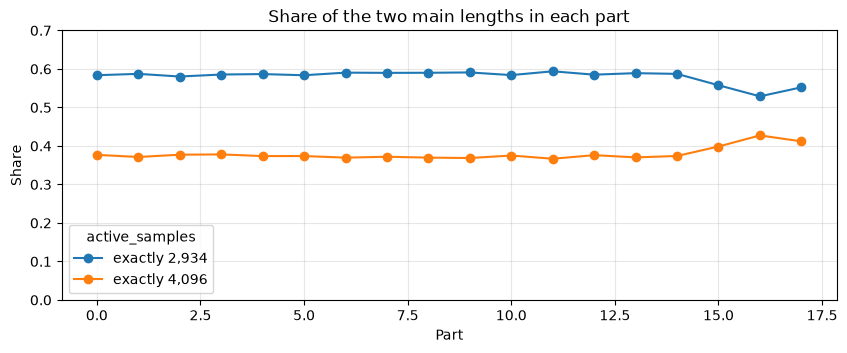

In [7]:
groups = pd.cut(padding["active_samples"], [-1, 0, 1999, 2933, 2934, 4095, 4096],
                labels=["all zero", "< 5 s", "5-7.3 s", "exactly 2,934", "7.3-10.24 s", "exactly 4,096"])
counts = groups.value_counts().sort_index()
display(pd.DataFrame({"tracings": counts, "share": (counts / counts.sum()).round(4)}))
centered = padding[padding["active_samples"] == 2934]
share_centered = ((centered["left"] == 581) & (centered["right"] == 581)).mean()
print(f"2,934-sample tracings padded exactly 581 + 581: {share_centered:.2%}")
by_part = pd.crosstab(padding["part"], groups, normalize="index")[["exactly 2,934", "exactly 4,096"]]
ax = by_part.plot(figsize=(10, 3.5), marker="o")
ax.set(title="Share of the two main lengths in each part", xlabel="Part", ylabel="Share", ylim=(0, 0.7))
plt.show()

**Finding: the duration question is answered.** 58% of all tracings have exactly 2,934 non-zero samples
(7.3 s), centered with 581 zeros on each side in 99.99% of cases, and 38% fill all 4,096 samples
(10.24 s). About 4% fall elsewhere, and 0.2% are all zero. The mix is the same in every part (parts
15-17 have slightly more full-length tracings), so this is a property of the dataset rather than of
one file. The project was right not to treat all 4,096 samples as signal: in most exams, 28% of the
stored samples are padding.

In [8]:
summary = code15_summary().join(exams, on="exam_id")
summary["length"] = np.where(summary["active_samples"] == 4096, "4,096 samples", "shorter")
display(problem_counts(summary).to_frame("tracings with at least 5 s of signal"))
medians = ["baseline_fraction", "high_frequency_fraction", "std", "peak_abs_mv", "heart_rate", "age"]
display(summary.groupby("length")[medians].median().round(4))
identities = ["einthoven_residual", "avf_residual", "avl_residual", "avr_residual"]
summary["limb_violated"] = summary[identities].max(axis=1) > 0.05
shares = summary.assign(large=summary["large_leads"] > 0, flat=summary["flat_leads"] > 0)
shares = shares.groupby("length")[["large", "flat", "limb_violated"]].mean()
display(shares.rename(columns={"large": "any lead over 10 units", "flat": "any lead flat 1 s",
                               "limb_violated": "limb identity violated"}).round(3))

,tracings with at least 5 s of signal
records,343809
any_nan,0
fully_constant_lead,1062
lead_flat_for_1s,5504
lead_over_10mv,40037
limb_identity_violated,80546
heart_rate_not_estimated,420


,baseline_fraction,high_frequency_fraction,std,peak_abs_mv,heart_rate,age
length,,,,,,
"4,096 samples",0.201,3.000e-04,0.404,5.685,70.588,54.0
shorter,0.005,2.600e-03,0.281,3.650,71.217,55.0


,any lead over 10 units,any lead flat 1 s,limb identity violated
length,,,
"4,096 samples",0.199,0.017,0.015
shorter,0.066,0.016,0.369


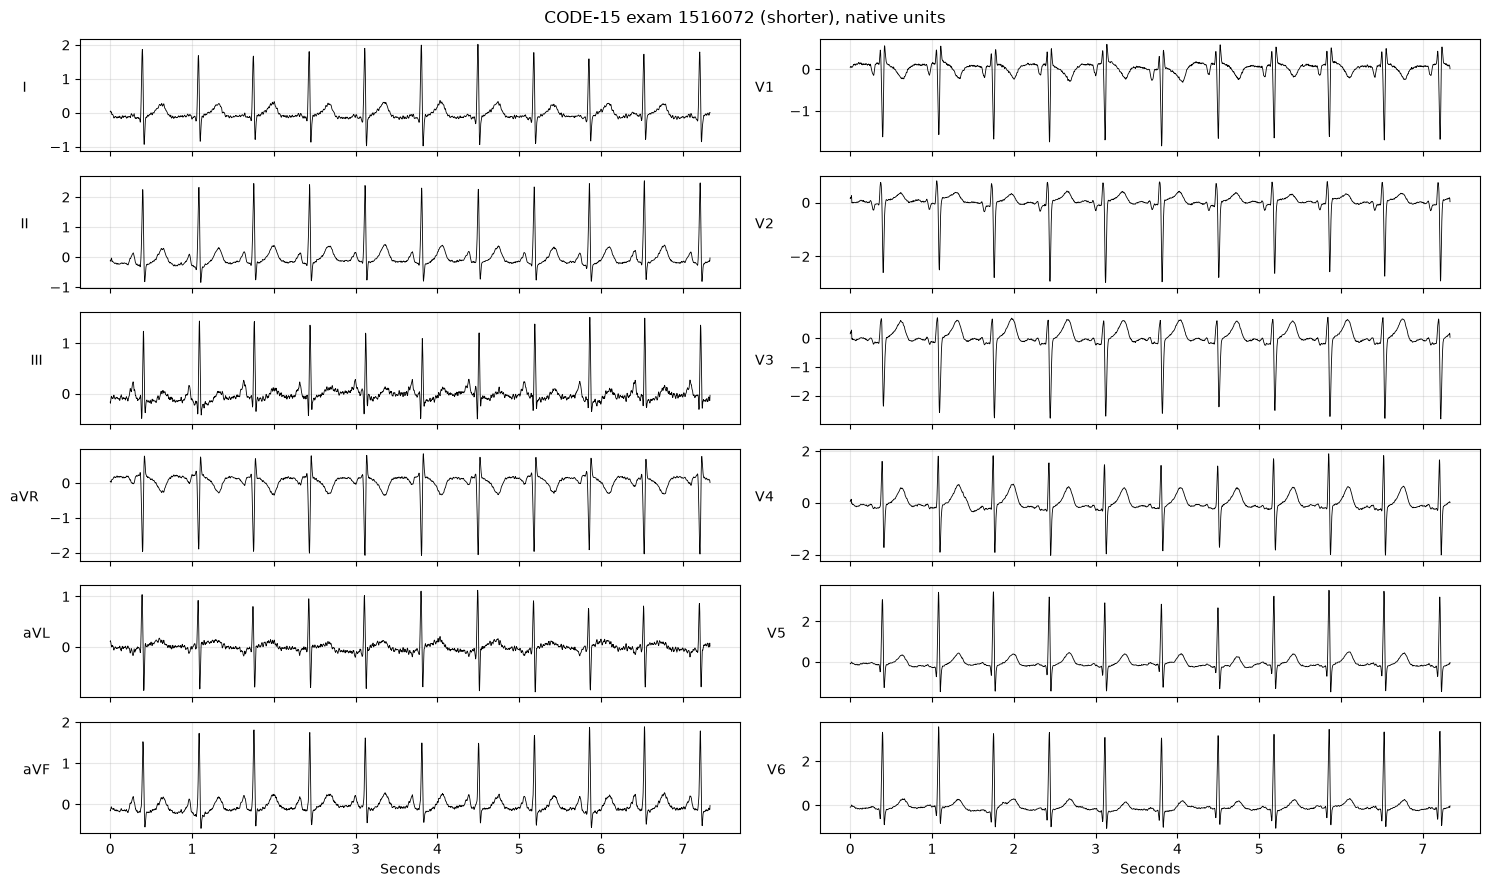

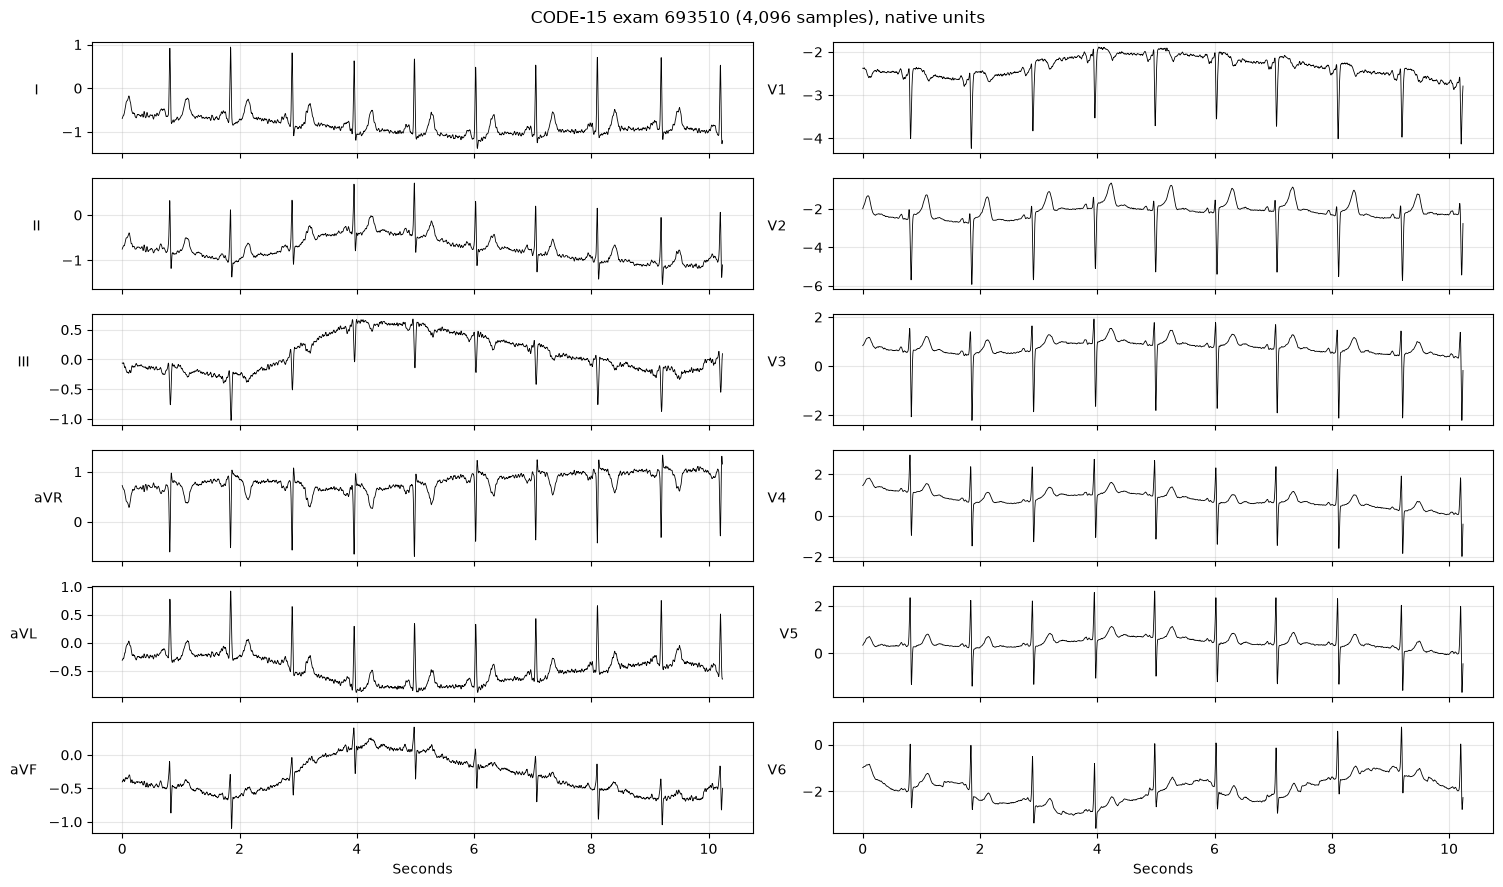

In [9]:
native_ids = set(pd.read_csv(PREPARED_DIR / "part0_native/manifest.csv")["exam_id"])
part0 = summary[(summary["part"] == 0) & summary["exam_id"].isin(native_ids)]
for group in ["shorter", "4,096 samples"]:
    row = part0[part0["length"] == group].sample(1, random_state=1).iloc[0]
    tracing = read_native_tracing(int(row["exam_id"]))
    active = tracing[int(row["left"]):len(tracing) - int(row["right"])]
    plot_ecg(active, 400, f"CODE-15 exam {int(row['exam_id'])} ({group}), native units", seconds=10.24)
    plt.show()

**Finding: the two lengths look like two acquisition pipelines.** The full-length (4,096-sample)
tracings have about 36x more low-frequency power, much less high-frequency power, larger amplitudes,
and a lead above 10 units in 20% of tracings (against 7%). The shorter tracings look filtered; the
long ones look raw, with baseline wander. The shorter group also breaks a limb-lead identity in 37% of
tracings against 2%, which suggests its leads were processed separately. Age and heart rate do not
differ, so this is acquisition rather than population. Anyone using CODE-15 should treat the length
group as a covariate.

## 5. Amplitude unit

The release does not state the unit of the stored values in a way the project could verify. We test
it empirically. If CODE values were mV, their amplitudes should resemble the other five sources, all of
which we have confirmed are in mV. We compare the signal range (99th minus 1st percentile) per lead,
restricted to ages 40-59 so that age differences do not explain the result.

,CODE-15,PTB-XL,ratio
lead,,,
I,1.628,0.810,2.009
II,1.756,0.806,2.179
III,1.221,0.596,2.049
aVR,1.604,0.766,2.094
aVL,1.155,0.577,2.002
aVF,1.260,0.571,2.206
V1,1.947,0.973,2.001
V2,2.511,1.586,1.583
V3,2.932,1.555,1.885


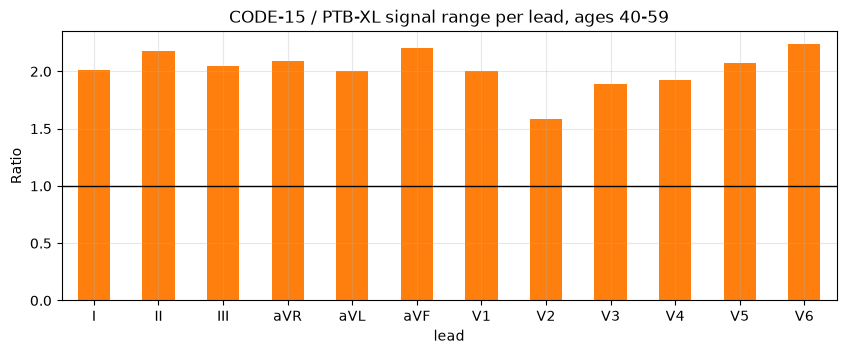

In [10]:
code15_leads = lead_features().join(exams["age"], on="exam_id")
ptbxl_leads = pd.read_parquet(PTBXL_FEATURES)
ptbxl_leads["ecg_id"] = ptbxl_leads["record_id"].astype(int)
ptbxl_leads = ptbxl_leads.join(load_metadata()["age"], on="ecg_id")
ranges = {}
for name, table in (("CODE-15", code15_leads), ("PTB-XL", ptbxl_leads)):
    middle_aged = table[(table["age"] >= 40) & (table["age"] < 60)]
    ranges[name] = (middle_aged["p99"] - middle_aged["p01"]).groupby(middle_aged["lead"]).median()
ranges = pd.DataFrame(ranges).loc[LEADS]
ranges["ratio"] = ranges["CODE-15"] / ranges["PTB-XL"]
display(ranges.round(3))
ax = ranges["ratio"].plot.bar(figsize=(10, 3.5), color="tab:orange", rot=0)
ax.axhline(1, color="black", linewidth=1)
ax.set(title="CODE-15 / PTB-XL signal range per lead, ages 40-59", ylabel="Ratio")
plt.show()

In [11]:
table = combined_summary()
spread = table.groupby("source")["std"].median().sort_values()
display(spread.to_frame("median signal std (native units)").round(3))

,median signal std (native units)
source,
mimic,0.133
georgia,0.143
cpsc_2018_extra,0.144
cpsc_2018,0.149
chapman_shaoxing,0.151
ptbxl,0.152
code15,0.316


**Finding: CODE-15 values are about twice as large as millivolts, uniformly across leads.** For the
same age range, every lead's range is 1.6-2.2 times PTB-XL's (median 2.03), and CODE-15's median signal
standard deviation is about twice that of all five mV-confirmed sources, which agree closely with each
other. A physiological difference (younger patients, different body habitus) would change limb and
precordial leads differently. A uniform factor of about 2 points to a scale difference in storage.
**CODE-15 cannot be pooled with the other sources until its values are rescaled.** The factor should be
confirmed with the dataset authors, or by matching a subset of exams whose amplitude is known, before
it is fixed in code.

## 6. Checking the sampling rate with the labels

The release states 400 Hz. If that were wrong, every heart rate we estimate would be off by the same
factor. The sinus tachycardia (`ST`) and sinus bradycardia (`SB`) flags give an independent check:
they are defined by rate (above 100 and below 60 bpm).

In [12]:
rates = pd.DataFrame({flag: summary.groupby(flag)["heart_rate"].median() for flag in ["ST", "SB", "AF"]}).T
rates.columns = ["flag absent", "flag present"]
display(rates.round(1))

,flag absent,flag present
ST,70.6,108.1
SB,71.2,47.2
AF,70.8,87.0


**Finding: 400 Hz is correct.** At the stated rate, exams flagged sinus tachycardia have a median
estimated heart rate of about 108 bpm, and exams flagged sinus bradycardia about 47 bpm, exactly on the
right side of the 100 and 60 bpm definitions. Unflagged exams sit around 71 bpm. The flags and the
waveforms are consistent.

## 7. The project's all-parts audit, reproduced

In [13]:
metadata = json.loads((PREPARED_DIR / "all_parts_manifest_v1/metadata.json").read_text())
ours = pd.Series({
    "audited": len(padding),
    "excluded_all_zero_signal": int((padding["active_samples"] == 0).sum()),
    "excluded_constant_lead": int((summary["constant_leads"] > 0).sum()),
})
display(pd.DataFrame({"project": pd.Series(metadata["counts"]), "this notebook": ours}))

,project,this notebook
accepted,340263,NaN
audited,345797,345797.0
excluded_all_zero_signal,670,688.0
excluded_constant_lead,1103,1062.0
excluded_duplicate_exam_id,17,NaN
excluded_duplicate_native_signal,3743,NaN
excluded_missing_csv_metadata,1,NaN
review_flagged,14413,NaN


**Finding: the project's audit is reproduced.** Both counts start from the same 345,797 stored
tracings. Our 688 all-zero tracings are the project's 670 plus the 18 filler rows, which it had
already excluded as 17 duplicate exam IDs and 1 row without CSV metadata. We find 1,062 tracings with a constant lead against the project's 1,103.
We only check tracings with at least 5 s of signal, which explains the small gap. Duplicate signals
(3,743 in the project's audit) were not re-checked here. The project's statement that units and
duration were unresolved was appropriately cautious; this notebook narrows both down.

## 8. Conclusions

**What is correct**

- All 345,779 exams have a stored tracing, and the export archive is complete and verified.
- Patient IDs are real, so patient-level splits are possible.
- 400 Hz is confirmed by the rate-defined labels, and the project's all-parts audit reproduces.
- The project did not use CODE-15 while units and duration were unresolved. That was the right call.

**What needs attention**

1. **The CODE-15 waveforms moved without a documentation update.** The acquisition receipt still points
   to ZIPs in `data/raw/`. Update the receipt and `docs/data-sources.md` to point to the export archive.
2. **Amplitudes are about 2x mV.** Rescale (after confirming the factor) before pooling with any other
   source.
3. **Two acquisition pipelines** (7.3 s filtered vs 10.24 s unfiltered). Crop to the active samples,
   drop the 18 filler rows and the 688 all-zero tracings, and keep the length group as a covariate.
4. **The labels do not map to the project's endpoint**: half the exams are abnormal in unspecified ways.

The last notebook puts all six sources side by side.